In [100]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [ ]:
%%bash
pip install icecream

In [ ]:
import sys

import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

sys.path.insert(0, "/content/drive/MyDrive/ABC-SN-workspace/ABC-SN/code")
import data_degrading as dg
import abcsn_training
import abcsn_config
import data_preparation as dp
import preprocessing as pp


sys.path.insert(0, "/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN")
from plot_data import *
from process_data import *

In [ ]:
keras.__version__

'3.13.2'

In [ ]:
file = "/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/data/full_preprocessed_dataframe.parquet"
master_df = pd.read_parquet(file)

In [ ]:
types, counts = np.unique(master_df.sn_type.values, return_counts = True)
for i in range(len(types)):
    print(types[i], " : ", counts[i])

CaRT  :  52
II  :  1819
IIb  :  542
IIn  :  880
Ia  :  8074
Iap  :  263
Ib  :  262
Ic  :  193
SL  :  1262
TDE  :  96


In [ ]:
# Choose the ones with ABC-SN labels only
index = ~np.isnan(master_df.ABC_type.values)
df = master_df[index]
df = df.reset_index(drop=True)

# creating y array to use for stratification
y = df["ABC_type"].values
index = df.index.values

In [ ]:
train_index, test_index = train_test_split(index, test_size = 0.3, random_state = 7, stratify = y)

In [ ]:
data = dp.extract_dataframe(df)

wvl = data[1]  # Wavelength array
flux0_columns = data[2]  # Columns that index the fluxes in the dataframe
df_metadata = data[5]  # Sub-dataframe containing only the metadata
fluxes0 = data[6]  # Only the flux values in a numpy array

In [ ]:
# one hot encode the y values
y_ohe = to_categorical(y, num_classes=10)

In [ ]:
X = fluxes0.copy()
X = X.reshape(X.shape[0],1,X.shape[1])

X_train = X[train_index]
X_test = X[test_index]

y_train = y_ohe[train_index]
y_test = y_ohe[test_index]

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7807, 1, 139), (3346, 1, 139), (7807, 10), (3346, 10))

In [ ]:
df_test = df.iloc[test_index].copy()

In [ ]:
df_test.ABC_type.unique()

array([0., 6., 1., 9., 4., 7.])

## Loading ABC-SN to make predictions


In [ ]:
# Loading model
# abcsn = keras.models.load_model("/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/ABCSN.keras", compile=False)
abcsn = keras.models.load_model("/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/ABCSN_finetuning100.keras", compile=False)


# need manually compile, using the code from ABC-SN/code/abcsn_training
loss = keras.losses.CategoricalCrossentropy()
acc = keras.metrics.CategoricalAccuracy(name="ca")
f1 = keras.metrics.F1Score(average="macro", name="f1")
lr0_transfer=1e-5
optimizer = keras.optimizers.Nadam(learning_rate=lr0_transfer)
abcsn.compile(loss=loss, optimizer=optimizer, metrics=[acc, f1])

In [ ]:
# Fine-tune from this layer onwards
fine_tune_at = len(abcsn.layers)-8

# Freeze all the layers before the `fine_tune_at` layer
for layer in abcsn.layers[:fine_tune_at]:
    layer.trainable = False

In [ ]:
for layer in abcsn.layers:
  print(layer, layer.trainable)

<InputLayer name=input_layer_1, built=True> False
<Dense name=dense_5, built=True> False
<Reshape name=reshape_2, built=True> False
<Dense name=dense_6, built=True> False
<SinePositionEncoding name=sine_position_encoding_1, built=True> False
<Dense name=dense_7, built=True> False
<Dense name=dense_8, built=True> False
<TransformerEncoder name=transformer_encoder_6, built=True> False
<TransformerEncoder name=transformer_encoder_7, built=True> False
<TransformerEncoder name=transformer_encoder_8, built=True> False
<TransformerEncoder name=transformer_encoder_9, built=True> False
<TransformerEncoder name=transformer_encoder_10, built=True> False
<TransformerEncoder name=transformer_encoder_11, built=True> False
<Flatten name=flatten, built=True> True
<Dense name=dense_9, built=True> True
<Dropout name=dropout_12, built=True> True
<Dense name=dense_10, built=True> True
<Dropout name=dropout_13, built=True> True
<Dense name=dense_11, built=True> True
<Dropout name=dropout_14, built=True> Tr

In [ ]:
abcsn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1, 139)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1, 1024)   │    143,360 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 64, 16)    │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64, 128)   │      2,176 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sine_position_enco… │ (None, 64, 128)   │          0 │ dense_6[0][0]     │
│ (SinePositionEncod… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64, 64)    │      8,256 │ sine_position_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64, 128)   │      8,320 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 128)   │          0 │ dense_6[0][0],    │
│                     │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ add_1[0][0]       │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8192)      │          0 │ transformer_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1024)      │  8,389,632 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 1024)      │          0 │ dense_9[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │    262,400 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 256)       │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 9,330,058 (35.59 MB)

 Trainable params: 9,167,946 (34.97 MB)

 Non-trainable params: 162,112 (633.25 KB)

In [ ]:
len(abcsn.trainable_variables)

104

## Retraining

In [ ]:
ABC_ID_dict = get_ABC_ID_dict()

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7807, 1, 139), (3346, 1, 139), (7807, 10), (3346, 10))

In [ ]:
if False:
  for i in range(9):
    print(f"Epoch {i}")
    epoch_start = 100 + 100*i
    epoch_end = 100 + 100*(i+1)

    history = abcsn.fit(X_train, y_train,
                        validation_data= (X_test, y_test),
                        epochs = epoch_end,    # choosen arbitrarily
                        initial_epoch=epoch_start,
                        batch_size = 64 # same as willow used
                        )

    abcsn.save("/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/ABCSN_finetuning"+ str(epoch_end) +".keras")

    hist_df = pd.DataFrame(history.history)
    hist_csv_file = '/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/ABCSN_finetuning'+ str(epoch_end) +'.csv'
    hist_df.to_csv(hist_csv_file)

Epoch 0
Epoch 101/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 38s 79ms/step - ca: 0.8687 - f1: 0.2404 - loss: 1.0340 - val_ca: 0.8670 - val_f1: 0.2244 - val_loss: 1.0640
Epoch 102/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 15s 67ms/step - ca: 0.8669 - f1: 0.2367 - loss: 1.0286 - val_ca: 0.8640 - val_f1: 0.2253 - val_loss: 1.0484
Epoch 103/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - ca: 0.8660 - f1: 0.2382 - loss: 1.0258 - val_ca: 0.8676 - val_f1: 0.2257 - val_loss: 1.0476
Epoch 104/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - ca: 0.8709 - f1: 0.2409 - loss: 1.0085 - val_ca: 0.8667 - val_f1: 0.2270 - val_loss: 1.0374
Epoch 105/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - ca: 0.8692 - f1: 0.2484 - loss: 1.0039 - val_ca: 0.8673 - val_f1: 0.2292 - val_loss: 1.0357
Epoch 106/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - ca: 0.8701 - f1: 0.2413 - loss: 0.9973 - val_ca: 0.8670 - val_f1: 0.2243 - val_loss: 1.0289
Epoch 107/200
122/122 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - ca: 0.8708 - f1: 0.2441 - loss: 

In [ ]:
hist_df = pd.read_csv("/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/ABCSN_finetuning200.csv")


for i in range(3,11):
  file = "/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/ABCSN_finetuning" +str(i)+ "00.csv"
  temp_df = pd.read_csv(file)
  print(file)
  hist_df = pd.concat([hist_df, temp_df])

/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/ABCSN_finetuning300.csv
/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/ABCSN_finetuning400.csv
/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/ABCSN_finetuning500.csv
/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/ABCSN_finetuning600.csv
/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/ABCSN_finetuning700.csv
/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/ABCSN_finetuning800.csv
/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/ABCSN_finetuning900.csv
/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/ABCSN_finetuning1000.csv


In [ ]:
hist_df = hist_df.reset_index(drop = True)
hist_df.to_csv("/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/ABCSN_finetuning_all.csv")

note the first epoch is actually 100


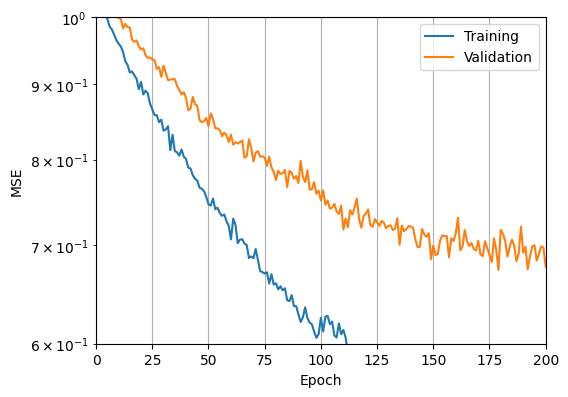

In [104]:
log = history.history
fig = abcsn_training.plot_loss(hist_df, scale=4, cb_es=None, patience_es=None)
plt.xlim(0, 200)
plt.ylim(0.6, 1)
print("note the first epoch is actually 100")
# want stop around 150- 175
# patience 25, delta 1*10 -2 1% improvement

## Results at the 400 epoch

In [ ]:
abcsn = keras.models.load_model("/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/ABCSN_finetuning400.keras", compile=False)

In [ ]:

# predict type
P = abcsn.predict(X_test, verbose=0)
P_argmax = np.argmax(P, axis=1)

df_test["Pred_ABC_ID"] = P_argmax

# get type as milligan ID
ABC_to_Mill = get_ABC_to_Mill_dict()
P_Mill = np.array([ABC_to_Mill[i] for i in P_argmax])
df_test["Pred_Mill_ID"] = P_Mill

Y_ABC_IDs = df_test.ABC_type.values

### Checking various types

In [ ]:
# true ABC ids
np.unique(Y_ABC_IDs, return_counts=True)

(array([0., 1., 4., 6., 7., 9.]), array([2422,   79,   78,  163,   58,  546]))

In [ ]:
# Predicted ABC id counts
np.unique(P_argmax, return_counts=True)

(array([0, 1, 4, 6, 7, 9]), array([2562,   33,   28,  109,   18,  596]))

In [ ]:
np.unique(P_Mill, return_counts=True)

(array([0, 1, 2]), array([2595,  155,  596]))

# Looking at the results of prediction with ABCSN labels

In [ ]:
Y_ABC_IDs = df_test.ABC_type.values

cr = (classification_report(
    Y_ABC_IDs,
    P_argmax,
    labels=list(ABC_subtype_id_to_str.keys()),
    target_names=list(ABC_subtype_id_to_str.values())
    ))

print(cr)
#may be skewed

              precision    recall  f1-score   support

     Ia-norm       0.92      0.98      0.95      2422
      Ia-91T       0.64      0.27      0.38        79
     Ia-91bg       0.00      0.00      0.00         0
         Iax       0.00      0.00      0.00         0
     Ib-norm       0.32      0.12      0.17        78
         Ibn       0.00      0.00      0.00         0
         IIb       0.80      0.53      0.64       163
     Ic-norm       0.33      0.10      0.16        58
    Ic-broad       0.00      0.00      0.00         0
         IIP       0.83      0.90      0.86       546

    accuracy                           0.89      3346
   macro avg       0.38      0.29      0.32      3346
weighted avg       0.87      0.89      0.87      3346



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

In [ ]:
np.unique(Y_ABC_IDs)
# what changed between the 9s and nans

array([0., 1., 4., 6., 7., 9.])

In [ ]:
df_test

,ABC_type,Mill_type,SN_mag,Spectral Phase,host,host_mag,redshift,sn_type,2512.529050300541,2537.7127325827696,...,9279.405394966827,9372.415104528947,9466.357072754703,9561.240643896645,9657.075255867012,9753.870441176497,9851.635827882466,9950.38114054659,Pred_ABC_ID,Pred_Mill_ID
2642,0.0,0.0,21.328,0.0,sb,23.906,0.203130,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
7125,0.0,0.0,17.907,0.0,sc,16.310,0.039275,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
6627,0.0,0.0,19.808,0.0,sb,21.986,0.201020,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
8561,0.0,0.0,21.387,0.0,sb,20.690,0.200820,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
8913,0.0,0.0,22.909,0.0,sc,22.655,0.342230,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5175,9.0,2.0,22.396,0.0,sa,22.390,0.245990,II,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,2
2245,0.0,0.0,22.500,0.0,sc,21.748,0.370850,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2713,0.0,0.0,22.285,0.0,sb,24.863,0.394130,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
279,0.0,0.0,22.746,0.0,sb,24.884,0.479130,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0


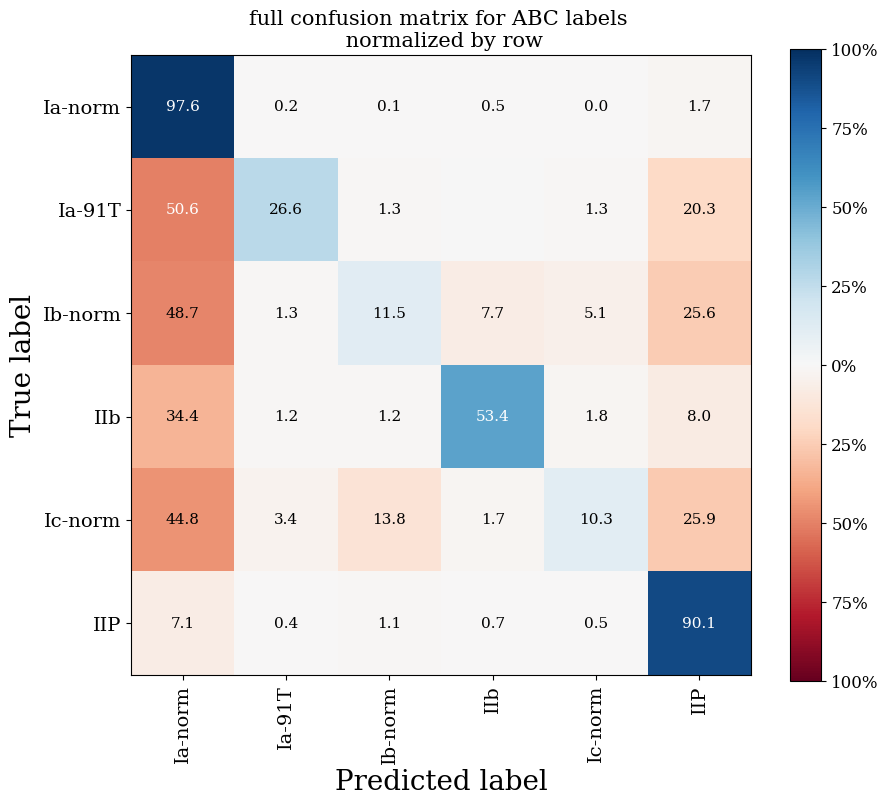

In [ ]:
ABC_ID_dict = get_ABC_ID_dict()
labels = [ABC_ID_dict[id] for id in np.unique(Y_ABC_IDs)]


cm = confusion_matrix(df_test.ABC_type.values,
                      df_test.Pred_ABC_ID.values,
                     labels = np.unique(Y_ABC_IDs))
plot = plot_cm(cm, labels,
               title = "full confusion matrix for ABC labels \n normalized by row",
              normalize = True)

## look at various normalizations

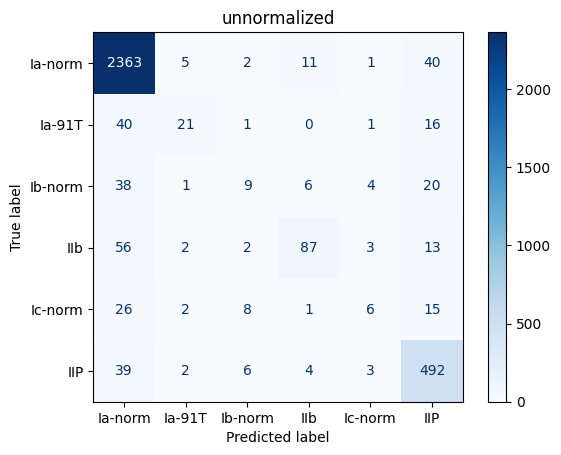

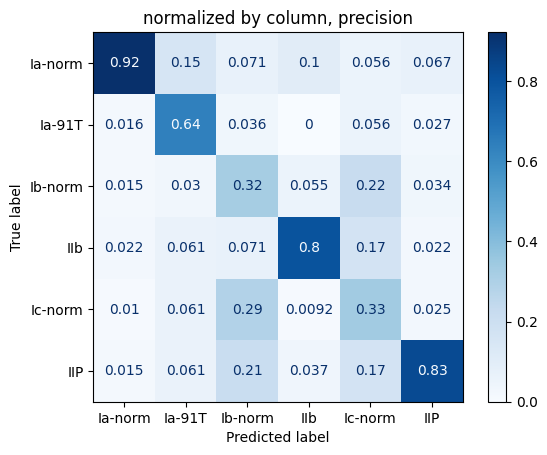

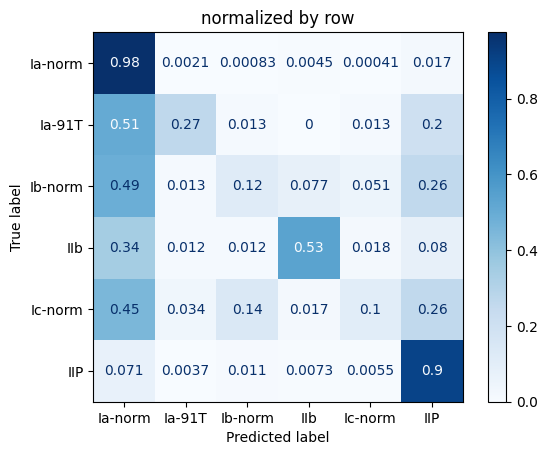

In [ ]:
normalizations = [None, "pred", "true"]
titles = ["unnormalized", "normalized by column, precision", "normalized by row"]

for i in range(3):
    cm = confusion_matrix(df_test.ABC_type.values,
                          df_test.Pred_ABC_ID.values,
                          labels=np.unique(Y_ABC_IDs)[:],
                          normalize=normalizations[i])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)
    disp.plot(cmap='Blues')
    plt.title(titles[i])
    plt.show()

## Looking at close and bright SN objects

In [ ]:

brighter_SN_index = df_test.host_mag > df_test.SN_mag + 1
small_z_index = df_test.redshift < 0.05
print(sum(small_z_index & brighter_SN_index))
bright_close_index = small_z_index & brighter_SN_index

bright_close_SN_df = df_test[bright_close_index].copy()

41


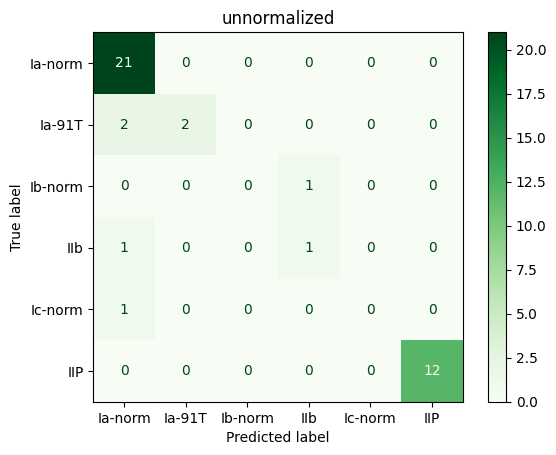

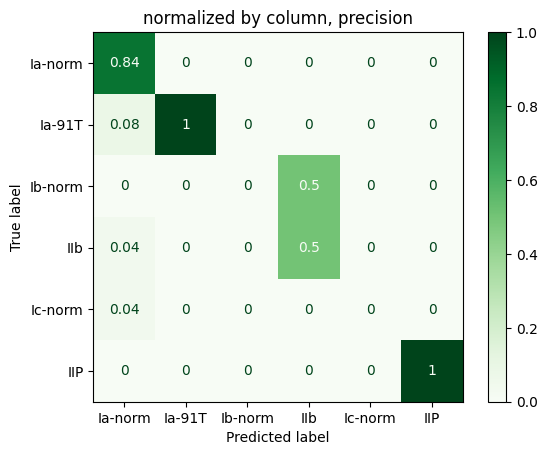

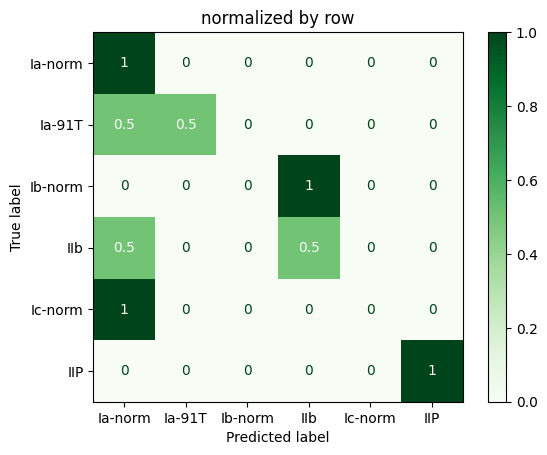

In [ ]:
normalizations = [None, "pred", "true"]
titles = ["unnormalized", "normalized by column, precision", "normalized by row"]

for i in range(3):
    cm = confusion_matrix(bright_close_SN_df.ABC_type.values,
                          bright_close_SN_df.Pred_ABC_ID.values,
                          labels=np.unique(Y_ABC_IDs),
                          normalize=normalizations[i])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)
    disp.plot(cmap='Greens')
    plt.title(titles[i])
    plt.show()

## Using Milligan Labels

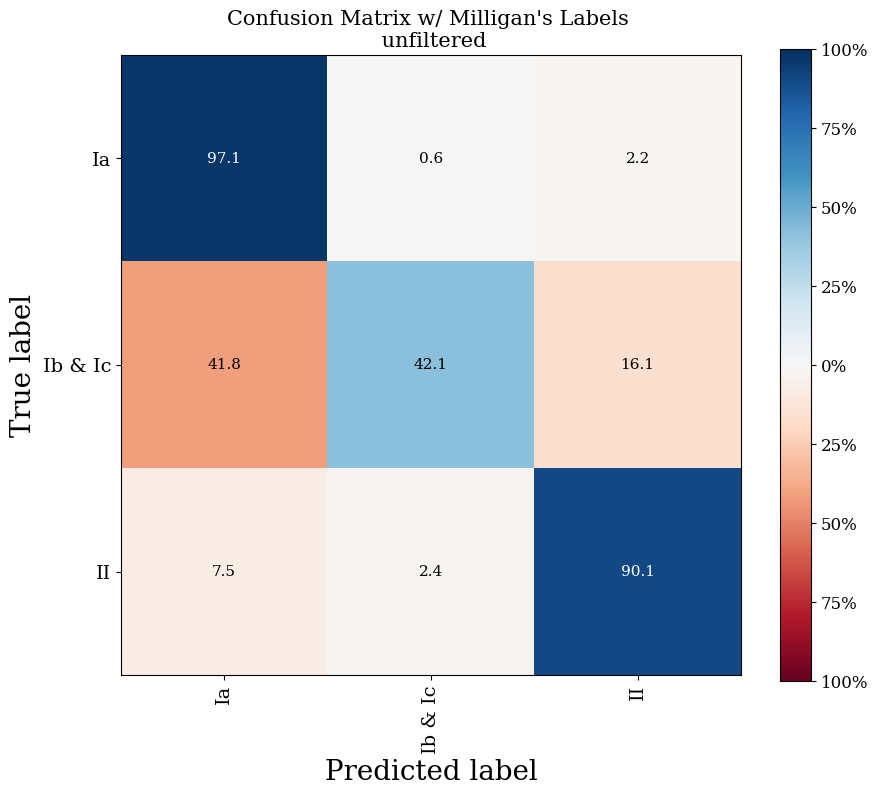

In [ ]:

cm_mill = confusion_matrix(df_test.Mill_type, df_test.Pred_Mill_ID,
                           labels=list(Mill_types_to_int.keys()))
plot = plot_cm(cm_mill[:3, :3], list(Mill_types_to_int.values())[:3],
        title = "Confusion Matrix w/ Milligan's Labels \n unfiltered")

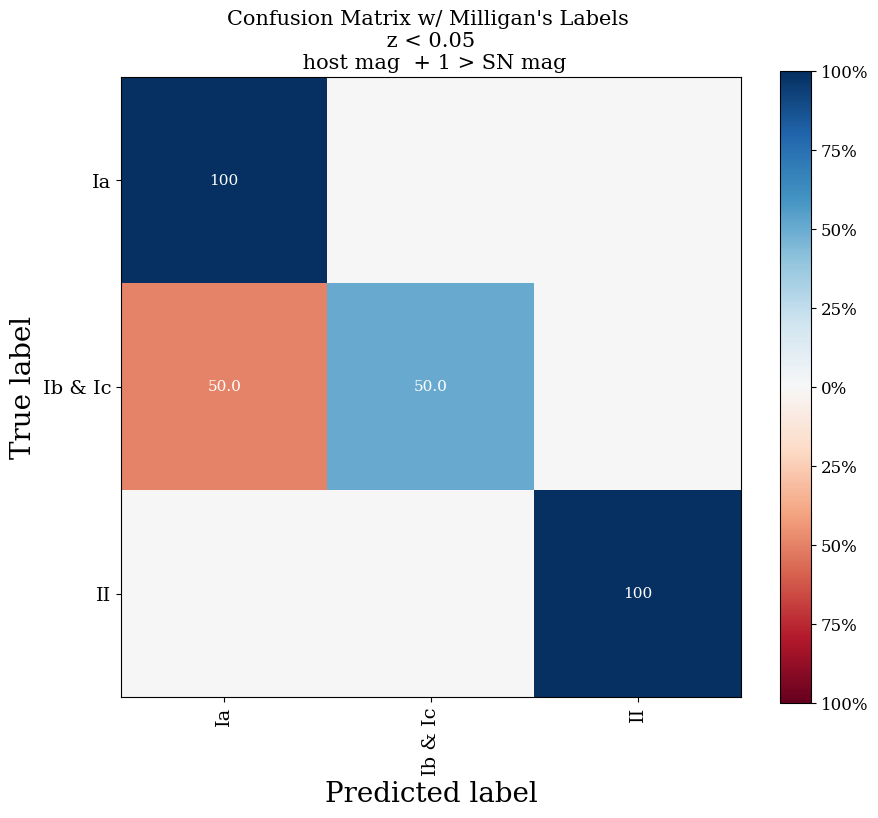

In [ ]:
cm_mill = confusion_matrix(bright_close_SN_df.Mill_type, bright_close_SN_df.Pred_Mill_ID,
                           labels=list(Mill_types_to_int.keys()))
plot = plot_cm(cm_mill[:3, :3], list(Mill_types_to_int.values())[:3],
        title = "Confusion Matrix w/ Milligan's Labels \n z < 0.05 \n host mag  + 1 > SN mag")

# Looking at classification spectra ... not particulary useful

/tmp/ipykernel_1263/2258145909.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_1263/2258145909.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_1263/2258145909.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_1263/2258145909.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_1263/2258145909.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")


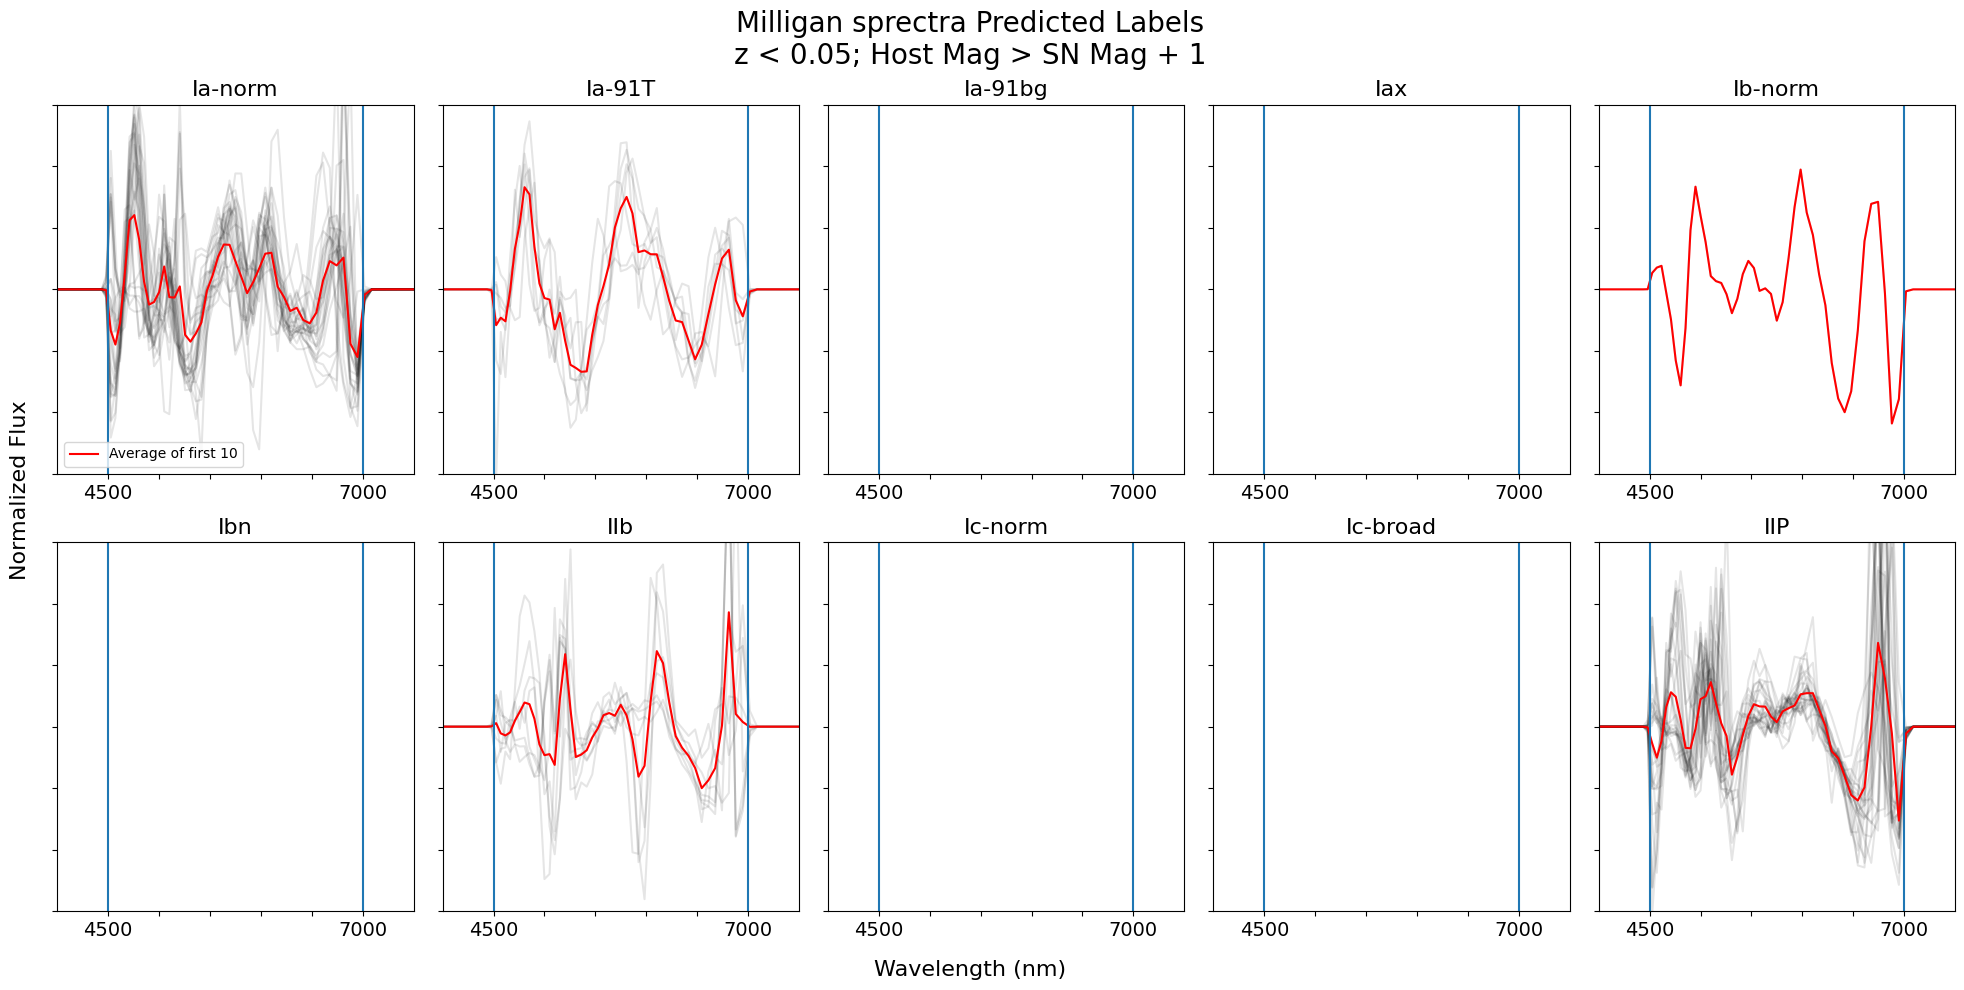

In [ ]:
types = list(ABC_subtype_id_to_str.keys())
types_titles = list(ABC_subtype_id_to_str.values())
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 10)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration
brighter_SN_index = df_test.host_mag > df_test.SN_mag +1
small_z_index = df_test.redshift < 0.05
close_bright_df = df_test[small_z_index] #df[brighter_SN_index & small_z_index]
num_wvl = 139
flux_start, flux_stop = 59, 103


for j, sn_type in enumerate(types):
    ax = axes[j]
    temp_df = close_bright_df[close_bright_df.Pred_ABC_ID == sn_type]

    dat_size = len(temp_df)
    X_temp = np.zeros((num_wvl, ))

    for n, i in enumerate(temp_df.index.values):
        if n < 10:
            X_temp += fluxes0[i]
        if n < 25:
            ax.plot(wvl, fluxes0[i], alpha = 0.1, color = "k")

    if dat_size < 10:
        ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
    else:
        ax.plot(wvl, X_temp/10 , alpha = 1, color = "r", label="Average of first 10")
    ax.set_title(f"{types_titles[j]}", fontsize = 16)
    ax.set_ylim(-3, 3)
    ax.set_xlim(4000,7500)
    ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
    ax.set_xticklabels(['', '', '', '', '', ''])
    ax.set_yticks([-3,-2,-1, 0, 1,2,3])
    ax.set_yticklabels(["", "", " ", " ", "", "", "" ])
    if j == 0:
        ax.legend()
    ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
    ax.set_xticklabels([4500, '', '', '', '', 7000], fontsize = 14)

    ax.axvline(4500)
    ax.axvline(7000)

fig.suptitle("Milligan sprectra Predicted Labels\nz < 0.05; Host Mag > SN Mag + 1", fontsize =20)

fig.supxlabel("Wavelength (nm)", fontsize = 16)
fig.supylabel("Normalized Flux\n", fontsize = 16)


plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
